# nb16b - The lender leak: how I found it, what caused it, and what fixing it cost

This notebook is a post-mortem. Notebook 16 and its two run variants (`refactor`, `lender`) are
the pipeline; this is the story of a bug that pipeline surfaced, why it was invisible to the
verification I had already written, and what the corrected answer is.

**The short version.** I ran the lender A/B on 7 August. Three of the four targets said the 13
Charges API features bought nothing. The fourth, `lending`, reported **precision@100 of 1.000**
against a base rate of 0.271%. That is not a good model, that is a leak, and it took about an hour
to find. The cause was the as-of gate: the lender features admitted a charge when it was **created**, not
when it became **visible**. Companies House gives you both dates and I used the wrong one.

Fixing it took two goes, which is the more useful lesson. Moving the gate to `delivered_on` removed
about half the distortion and the model was still scoring P@500 = 0.742. Delivery is not
registration: Companies House takes about three weeks to process a delivered charge into the
register that the label is computed from. The gate that finally holds is `delivered_on` plus a
**measured** 21-day registration lag.

Everything below re-derives the evidence from what is on disk, so anyone can check it.

## Setup

In [1]:
import json
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import charges
from src.models import targets, train

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("PRAGMA threads=6")

FLAT    = charges.FLAT_PATH.as_posix()
PANEL   = (Path("data/processed/panel") / "**" / "*.parquet").as_posix()
LEAKY   = (Path("data/processed/lender_panel") / "**" / "*.parquet").as_posix()
FIXED   = (Path("data/processed/lender_panel_fixed") / "**" / "*.parquet").as_posix()
ASOF21  = (Path("data/processed/lender_panel_asof21") / "**" / "*.parquet").as_posix()

---

# 1. The symptom

The A/B was supposed to answer one question: did 25 hours of Charges API harvesting buy predictive
power? Here is what came back.

In [2]:
auc = train.compare_runs(["baseline", "refactor", "lender"], metric="roc_auc").round(4)
p500 = train.compare_runs(["baseline", "refactor", "lender"], metric="precision_at_500").round(3)
p100 = train.compare_runs(["baseline", "refactor", "lender"], metric="precision_at_100").round(3)
print("ROC-AUC (lightgbm)"); print(auc.to_string())
print("\nprecision@500"); print(p500.to_string())
print("\nprecision@100"); print(p100.to_string())

ROC-AUC (lightgbm)
tag             baseline  lender  refactor
target                                    
growth            0.7620  0.7615    0.7620
insolvency        0.7615  0.7621    0.7615
lending           0.8767  0.8951    0.8767
voluntary_exit    0.7929  0.7931    0.7929

precision@500
tag             baseline  lender  refactor
target                                    
growth             0.202   0.178     0.202
insolvency         0.122   0.114     0.122
lending            0.282   0.992     0.282
voluntary_exit     0.848   0.846     0.854

precision@100
tag             baseline  lender  refactor
target                                    
growth              0.22    0.24      0.22
insolvency          0.19    0.18      0.19
lending             0.55    1.00      0.55
voluntary_exit      0.83    0.78      0.82


Read the `lending` row across the two tables and the problem announces itself.

- ROC-AUC goes 0.8767 to 0.8951. A real but unremarkable improvement.
- precision@100 goes 0.55 to **1.000**. Every single one of the top hundred was right.
- precision@500 goes 0.282 to **0.992**, a lift of 366x over the base rate.

**Those two things cannot both be honest.** ROC-AUC is a global statement: pick a positive and a
negative at random, how often is the positive ranked higher. precision@N is a local statement about
the very top of the list. A model that genuinely got much better at ranking would move both. A model
that has been handed the answer for a *subset* of companies moves precision@N to nearly 1 and leaves
ROC-AUC almost alone, because that subset is small relative to the 2.8 million rows the AUC is
computed over.

That gap between a global metric and a local one is the whole tell, and it is the reason I record
both. If I had only tracked AUC I would have shipped this.

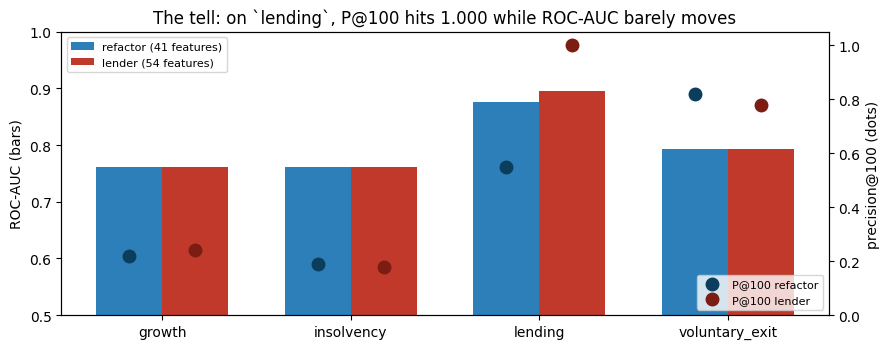

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(auc.index))
w = 0.35
ax.bar(x - w/2, auc["refactor"], w, label="refactor (41 features)", color="#2c7fb8")
ax.bar(x + w/2, auc["lender"], w, label="lender (54 features)", color="#c0392b")
ax2 = ax.twinx()
ax2.plot(x - w/2, p100["refactor"], "o", ms=9, color="#0b3d5c", label="P@100 refactor")
ax2.plot(x + w/2, p100["lender"], "o", ms=9, color="#7b1d12", label="P@100 lender")
ax.set_xticks(x); ax.set_xticklabels(auc.index)
ax.set_ylim(0.5, 1.0); ax2.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC (bars)"); ax2.set_ylabel("precision@100 (dots)")
ax.set_title("The tell: on `lending`, P@100 hits 1.000 while ROC-AUC barely moves")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

---

# 2. Ruling out the boring explanations

Before hunting for a leak I checked the things that are far more often the cause: a different
evaluation population, a selection effect, or one obviously broken column.

**Is it the same test set?** If the lender matrix quietly dropped or added rows, the two runs would
not be comparable and the precision would be measured over a different denominator.

In [4]:
rows = []
for tag in ("refactor", "lender"):
    met = json.loads(Path(f"reports/runs/{tag}/metrics.json").read_text())["targets"]
    for t, r in met.items():
        m = r["metrics"]["lightgbm"]
        rows.append({"tag": tag, "target": t, "eval_rows": m["n"],
                     "positives": m["positives"], "base_rate": m["base_rate"]})
pd.DataFrame(rows).pivot(index="target", columns="tag",
                         values=["eval_rows", "positives"])

eval_rows          positives         
tag               lender refactor    lender refactor
target                                              
growth           1817119  1817119     38833    38833
insolvency       2779612  2779612      9156     9156
lending          2782591  2782591      7544     7544
voluntary_exit   2779612  2779612    214797   214797

Identical, target by target. Same rows, same positives, so the A/B is genuinely like for like and
the denominator is not the story.

**Is it a selection effect?** The lender panel only covers companies that have ever held a charge.
If the lender features were NULL for everyone else, then "has a lender row at all" would itself be a
signal, and one that partly encodes the future (the harvest happened at the end of the window).

In [5]:
CFG = train.LENDER
sp = train.split_origins("lending", CFG)
te = train.load_origins("lending", sp.test, CFG.eval_dir,
                        [c for c in targets.FEATURE_COLS_LENDER
                         if c not in targets.FEATURE_COLS], ["primary_lender_group"])
y = te["y"].to_numpy()
has_lender = te["n_charges_outstanding"].notna()
print(f"eval rows                : {len(te):,}")
print(f"rows with lender features: {has_lender.sum():,} ({has_lender.mean():.2%})")
print(f"label rate               : {y.mean():.4%}")

eval rows                : 2,782,591
rows with lender features: 2,782,591 (100.00%)
label rate               : 0.2711%


100%. The join coalesces "never held a charge" to 0 rather than leaving NULL, so every row has
lender features and mere presence carries no information. Not a selection effect either.

**Is one column obviously broken?** If a single feature were a copy of the label, ranking on that
feature alone would reproduce the near-perfect precision.

In [6]:
extra = [c for c in targets.FEATURE_COLS_LENDER if c not in targets.FEATURE_COLS]
rows = []
for c in extra:
    if c == "primary_lender_group":
        continue
    x = pd.to_numeric(te[c], errors="coerce").to_numpy(dtype=float)
    for sign, lbl in ((1, "high first"), (-1, "low first")):
        v = np.where(np.isnan(sign * x), -np.inf, sign * x)
        rows.append({"feature": c, "ranked": lbl,
                     "P@500 alone": y[np.argsort(-v)[:500]].mean()})
(pd.DataFrame(rows).sort_values("P@500 alone", ascending=False)
   .head(8).style.format({"P@500 alone": "{:.3f}"}))

,feature,ranked,P@500 alone
20,competitor_charge_created_6m,high first,0.162
13,months_since_last_lbg_charge_created,low first,0.162
0,n_charges_outstanding,high first,0.134
15,months_since_last_lbg_satisfaction,low first,0.106
10,n_competitor_lenders,high first,0.094
8,n_distinct_lenders,high first,0.090
16,competitor_entered_12m,high first,0.084
2,n_lbg_charges_outstanding,high first,0.080


The best single feature manages 0.164. The model gets 0.992. So no one column is the culprit; the
model is combining them. That is what made this worth chasing rather than obvious.

---

# 3. The cause: two dates, and I used the wrong one

Every charge in the Companies House API carries **`created_on`**, the date the charge was made, and
**`delivered_on`**, the date it was delivered to Companies House and became visible to anyone
looking. They are not the same date, and the gap is not small.

charges              572763.0
pct_delivered_later      94.7
median_lag_days           6.0
p90_lag_days             16.0


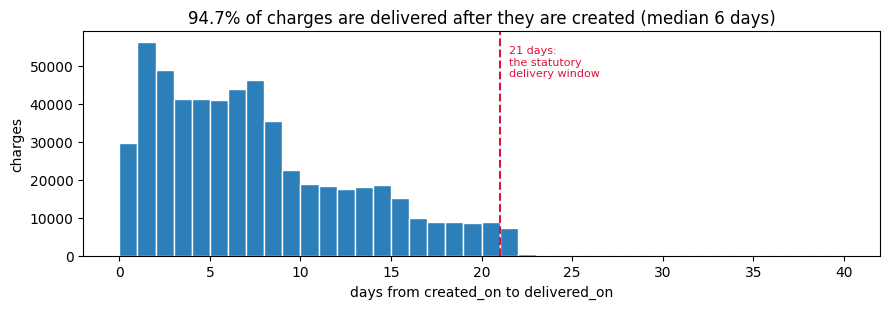

In [7]:
lag = con.execute(f'''
    SELECT datediff('day', created_on, delivered_on) AS lag_days
    FROM read_parquet('{FLAT}')
    WHERE created_on IS NOT NULL AND delivered_on IS NOT NULL
      AND datediff('day', created_on, delivered_on) BETWEEN 0 AND 40
''').df()

summary = con.execute(f'''
    SELECT count(*) AS charges,
           round(100.0*avg(CASE WHEN delivered_on > created_on THEN 1 ELSE 0 END), 1) AS pct_delivered_later,
           median(datediff('day', created_on, delivered_on)) AS median_lag_days,
           quantile_cont(datediff('day', created_on, delivered_on), 0.9) AS p90_lag_days
    FROM read_parquet('{FLAT}')
    WHERE created_on IS NOT NULL AND delivered_on IS NOT NULL
''').df()
print(summary.T.to_string(header=False))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(lag["lag_days"], bins=range(0, 41), color="#2c7fb8", edgecolor="white")
ax.axvline(21, color="crimson", ls="--", lw=1.5)
ax.text(21.5, ax.get_ylim()[1]*0.8, "21 days:\nthe statutory\ndelivery window",
        color="crimson", fontsize=8)
ax.set_xlabel("days from created_on to delivered_on")
ax.set_ylabel("charges")
ax.set_title("94.7% of charges are delivered after they are created (median 6 days)")
plt.tight_layout(); plt.show()

Now put that next to what the gate actually said. From `src/features/charges.py`, the join that
decides whether a charge counts in month `t` read:

```sql
JOIN charges c
  ON  c."CompanyNumber" = s."CompanyNumber"
 AND  c.created_on <= s.snapshot_date        --  <-- the bug
```

So a charge **created** on 20 January and **delivered** on 28 January was counted in the feature row
for 1 January. Meanwhile the `lending` label is computed from the bulk register's charge count, and
the bulk register cannot see a charge that has not been delivered to it yet. The label therefore
resolves as a 1, and the feature row already knew.

The model did not learn anything about lending. It learned to read a charge that had already
happened.

In [8]:
leaky_months = con.execute(f'''
    WITH months AS (
        SELECT UNNEST(generate_series(DATE '2023-10-01', DATE '2026-07-01',
                                      INTERVAL 1 MONTH))::DATE AS m)
    SELECT count(*) AS charge_months_counted_before_observable
    FROM read_parquet('{FLAT}') c, months
    WHERE c.created_on <= months.m AND c.delivered_on > months.m
''').df()
print(leaky_months.to_string(index=False))

 charge_months_counted_before_observable
                                   12182


### How much did that distort the features?

The sharpest way to see it: take company-months that **do** go on to borrow in the next three
months, and compare the API's outstanding count at `t` against the bulk register's. If the features
were honest, the two would agree at `t` and the borrowing would show up only later.

In [9]:
def gap_check(lender_glob, label):
    return con.execute(f'''
    WITH j AS (
      SELECT g.n_charges_outstanding AS api_t,
             p0."Mortgages.NumMortOutstanding" AS bulk_t,
             p3."Mortgages.NumMortOutstanding" AS bulk_t3
      FROM read_parquet('{lender_glob}', hive_partitioning=true) g
      JOIN read_parquet('{PANEL}', hive_partitioning=true) p0
        ON p0."CompanyNumber"=g."CompanyNumber" AND p0.snapshot_date=g.snapshot_date
      JOIN read_parquet('{PANEL}', hive_partitioning=true) p3
        ON p3."CompanyNumber"=g."CompanyNumber"
       AND p3.snapshot_date = g.snapshot_date + INTERVAL 3 MONTH
      WHERE g.snapshot_date BETWEEN DATE '2025-10-01' AND DATE '2026-04-01'
        AND p3."Mortgages.NumMortOutstanding" > p0."Mortgages.NumMortOutstanding")
    SELECT '{label}' AS gate,
           count(*) AS company_months,
           round(avg(api_t - bulk_t), 4) AS mean_api_minus_bulk,
           round(100.0*avg(CASE WHEN api_t = bulk_t3 THEN 1 ELSE 0 END), 1) AS pct_already_at_future_value
    FROM j''').df()

pd.concat([gap_check(LEAKY,  "1. created_on (leaky)"),
           gap_check(FIXED,  "2. delivered_on"),
           gap_check(ASOF21, "3. delivered_on + 21d")], ignore_index=True)

,gate,company_months,mean_api_minus_bulk,pct_already_at_future_value
0,1. created_on (leaky),15713,0.2936,19.2
1,2. delivered_on,15089,0.1593,9.7
2,3. delivered_on + 21d,14428,0.0136,1.3


Under the old gate, for companies about to borrow, the API count already sat **0.29 charges above**
the register, and for **19.2% of them it had already reached the post-borrowing value**. Across the
whole population that same gap is only about 0.05, so the discrepancy is six times larger precisely
where it does damage.

### The direct test

Mechanism established, the last question is whether it actually explains the model's behaviour. So:
of the 500 companies the model ranked highest, how many were holding a charge that had been counted
before it was observable?

In [10]:
import pickle

sp = train.split_origins("lending", CFG)
cols, cats = CFG.cols(), CFG.cats()
te_full = train.load_origins("lending", sp.test, CFG.eval_dir, cols, cats)
tr_full = train.load_origins("lending", sp.train, CFG.matrix_dir, cols, cats)
train.align_categories([tr_full, te_full], cats)

with open("data/processed/run_stage/lender/model_lending.pkl", "rb") as fh:
    gbm = pickle.load(fh)["lightgbm"]
p = gbm.predict_proba(train.feature_frame(te_full, cols))[:, 1]
yy = te_full["y"].to_numpy()
top = np.argsort(-p)[:500]
print(f"reproduced P@500 = {yy[top].mean():.3f}, P@100 = {yy[np.argsort(-p)[:100]].mean():.3f}")

keys = te_full.iloc[top][["CompanyNumber", "origin_month"]]
con.register("k", keys)
con.register("allrows", te_full[["CompanyNumber", "origin_month"]])
q = '''
SELECT round(100.0*avg(CASE WHEN leaky THEN 1 ELSE 0 END), 2) AS pct_holding_a_leaky_charge
FROM (SELECT EXISTS (SELECT 1 FROM read_parquet('{flat}') c
                     WHERE c."CompanyNumber" = s."CompanyNumber"
                       AND c.created_on   <= s.origin_month
                       AND c.delivered_on  > s.origin_month) AS leaky
      FROM ({src}) s)
'''
top500 = con.execute(q.format(flat=FLAT, src="SELECT * FROM k")).df().iloc[0, 0]
popn = con.execute(q.format(flat=FLAT,
                            src="SELECT * FROM allrows USING SAMPLE 20000 ROWS")).df().iloc[0, 0]
print(f"\nmodel's top 500      : {top500}% hold a charge counted before it was observable")
print(f"population (20k sample): {popn}%")
print(f"enrichment            : {top500/max(popn, 1e-9):,.0f}x")

reproduced P@500 = 0.992, P@100 = 1.000



model's top 500      : 46.6% hold a charge counted before it was observable
population (20k sample): 0.01%
enrichment            : 4,660x


**46.6% against 0.01%.** Nearly half the model's call list is companies whose "future" borrowing had
already been written into their features, against one in ten thousand across the population. That is
the leak, measured rather than argued.

---

# 4. The fix, and why my existing verification missed it

One word, in `src/features/charges.py`. The charge CTE now computes the date at which a charge became
*observable* and every as-of gate uses that:

```sql
GREATEST(created_on, COALESCE(delivered_on, created_on)) AS observable_on
...
AND c.observable_on <= s.snapshot_date
```

`GREATEST` because a few rows carry a delivered date earlier than the created date, and `COALESCE`
because a few carry no delivered date at all. The same substitution was made in the 6- and 12-month
window counts, so "a competitor charge arrived in the last 6 months" now means "we could see one
arrive", which is the only version of that sentence a model standing at `t` is entitled to.

**Why verification 7 in notebook 14b did not catch this**, which is the part I find most instructive.
That test truncates the harvest at a cut date and rebuilds the panel, checking that nothing after the
cut leaks in. But it truncates **on `created_on`**, the same wrong clock. So it faithfully verified
that no charge *created* after the cut appeared, and never asked whether a charge created before the
cut was *knowable* by then. A blind-replay test is only ever as good as the clock you replay against,
and mine had the bug built into the test as well as the code.

This is the same distinction the contract features already got right, where everything is gated on
`publication_date` rather than `signature_date` because a contract signed in March and published in
May must not be visible in March. Identical trap, caught in one pipeline and walked into in the other.

---

# 5. The rebuild, and the second clock

`lender_panel_fixed/`, `model_matrix_lender_fixed/` and the `lender_fixed` run sit beside the leaky
ones rather than replacing them, because the before/after **is** the finding.

The gap table in section 3 already shows what `delivered_on` bought: the mean API-minus-register gap
for about-to-borrow companies falls from 0.29 to 0.16, and the share already sitting at the future
value falls from 19.2% to 9.7%. Better, and **not zero**.

I nearly stopped there. What stopped me stopping was re-running the model: `lending` came back at
P@500 = **0.742**, against the 41-feature control's 0.282. Still obviously wrong. So the gate was
still too generous.

The residual is a second clock. Companies House does not register a charge the instant it is
delivered, and the monthly bulk extract is itself taken on a drifting date (`ch_bulk.MANIFEST` holds
real file dates like `2023-10-04` and `2024-02-07`, not the 1st). So a charge delivered shortly
before a snapshot is visible in the API and still absent from the register file that defines the
label.

Rather than guess a safety margin I measured one: sweep the margin, and for each value compare the
API's outstanding count at `t` against the register's, over the company-months that go on to borrow.

 margin_days  mean_api_minus_bulk  pct_at_future_value
           0               0.1014                 6.16
          14               0.0121                 0.81
          21               0.0013                 0.79
          30              -0.0128                 0.78
          45              -0.0314                 0.72
          60              -0.0511                 0.70


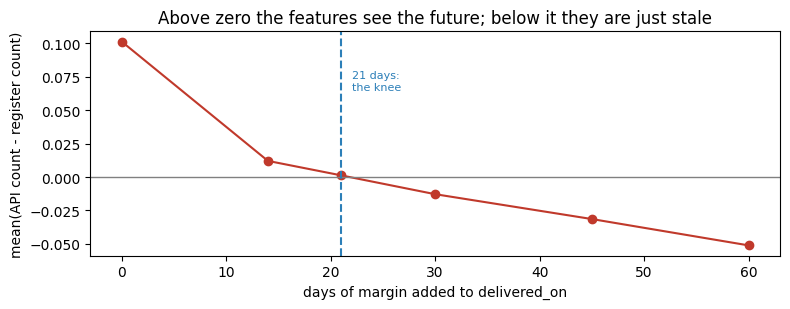

In [11]:
sweep = []
for margin in (0, 14, 21, 30, 45, 60):
    sweep.append(con.execute(f'''
    WITH obs AS (
      SELECT "CompanyNumber", charge_id, satisfied_on,
             GREATEST(created_on, COALESCE(delivered_on, created_on)) AS observable_on
      FROM read_parquet('{FLAT}') WHERE created_on IS NOT NULL),
    base AS (
      SELECT p0."CompanyNumber", p0.snapshot_date,
             p0."Mortgages.NumMortOutstanding" AS bulk_t,
             p3."Mortgages.NumMortOutstanding" AS bulk_t3
      FROM read_parquet('{PANEL}', hive_partitioning=true) p0
      JOIN read_parquet('{PANEL}', hive_partitioning=true) p3
        ON p3."CompanyNumber"=p0."CompanyNumber"
       AND p3.snapshot_date = p0.snapshot_date + INTERVAL 3 MONTH
      WHERE p0.snapshot_date BETWEEN DATE '2025-10-01' AND DATE '2026-04-01'
        AND p3."Mortgages.NumMortOutstanding" > p0."Mortgages.NumMortOutstanding"),
    api AS (
      SELECT b."CompanyNumber", b.snapshot_date, b.bulk_t, b.bulk_t3,
             count(DISTINCT CASE WHEN o.satisfied_on IS NULL
                                   OR o.satisfied_on > b.snapshot_date
                                 THEN o.charge_id END) AS api_t
      FROM base b LEFT JOIN obs o
        ON o."CompanyNumber" = b."CompanyNumber"
       AND o.observable_on <= b.snapshot_date - INTERVAL {margin} DAY
      GROUP BY 1,2,3,4)
    SELECT {margin} AS margin_days,
           round(avg(api_t - bulk_t), 4) AS mean_api_minus_bulk,
           round(100.0*avg(CASE WHEN api_t = bulk_t3 THEN 1 ELSE 0 END), 2) AS pct_at_future_value
    FROM api''').df())

sweep = pd.concat(sweep, ignore_index=True)
print(sweep.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(sweep["margin_days"], sweep["mean_api_minus_bulk"], "o-", color="#c0392b")
ax.axhline(0, color="grey", lw=1)
# 21 as a literal, not charges.REGISTRATION_LAG_DAYS: section 8 recalibrates that
# constant and this cell is the historical record of how I first got to 21.
ax.axvline(21, color="#2c7fb8", ls="--", lw=1.5)
ax.text(22, ax.get_ylim()[1]*0.6, "21 days:\nthe knee", color="#2c7fb8", fontsize=8)
ax.set_xlabel("days of margin added to delivered_on")
ax.set_ylabel("mean(API count - register count)")
ax.set_title("Above zero the features see the future; below it they are just stale")
plt.tight_layout(); plt.show()

Zero margin still leaves the API a tenth of a charge ahead of the register. At 21 days the
discrepancy is **+0.0013**, and pushing further buys nothing (0.79% at 21 days, 0.78% at 30, 0.70%
at 60) while the gap turns negative, which is the features going stale rather than getting safer.

So the gate is `delivered_on + 21 days`, recorded as `charges.REGISTRATION_LAG_DAYS` with this table
next to it so the number reads as a measurement rather than a guess.

*(Written on the day. `charges.REGISTRATION_LAG_DAYS` is no longer 21: section 8 takes this sweep apart and finds that most of those days belong to a clock I had not lagged at all. I have left this section exactly as it stood, because the sequence of wrong answers is the finding.)*

In [12]:
resid = con.execute(f'''
WITH j AS (
  SELECT g.snapshot_date, g."CompanyNumber", g.n_charges_outstanding AS api_t,
         p3."Mortgages.NumMortOutstanding" AS bulk_t3
  FROM read_parquet('{FIXED}', hive_partitioning=true) g
  JOIN read_parquet('{PANEL}', hive_partitioning=true) p0
    ON p0."CompanyNumber"=g."CompanyNumber" AND p0.snapshot_date=g.snapshot_date
  JOIN read_parquet('{PANEL}', hive_partitioning=true) p3
    ON p3."CompanyNumber"=g."CompanyNumber"
   AND p3.snapshot_date = g.snapshot_date + INTERVAL 3 MONTH
  WHERE g.snapshot_date BETWEEN DATE '2025-10-01' AND DATE '2026-04-01'
    AND p3."Mortgages.NumMortOutstanding" > p0."Mortgages.NumMortOutstanding"
    AND g.n_charges_outstanding = p3."Mortgages.NumMortOutstanding")
SELECT quantile_cont(datediff('day', c.delivered_on, j.snapshot_date),
                     [0.1, 0.25, 0.5, 0.75, 0.9]) AS days_delivered_before_snapshot
FROM j JOIN read_parquet('{FLAT}') c
  ON c."CompanyNumber" = j."CompanyNumber"
 AND c.delivered_on <= j.snapshot_date
 AND c.delivered_on > j.snapshot_date - INTERVAL 3 MONTH
''').df()
print("For the cases that still look early, how long before the snapshot were they delivered?")
print("quantiles [10, 25, 50, 75, 90]:", resid.iloc[0, 0])

For the cases that still look early, how long before the snapshot were they delivered?
quantiles [10, 25, 50, 75, 90]: [ 0.  1.  3.  6. 11.]


Delivered a median of 3 days before the snapshot, 90% of them within 11 days. That is the register's
processing lag, not a mistake in the feature code, and closing it properly means gating the lender
features on the date the bulk file was actually extracted rather than on the nominal first of the
month. Whether that is worth doing is a question about how much distortion is left, which is what the
next section measures rather than guesses.

---

# 6. The corrected answer

This is the table the whole exercise exists to produce.

In [13]:
tags = ["baseline", "refactor", "lender", "lender_fixed", "lender_asof21"]
for metric in ("roc_auc", "precision_at_100", "precision_at_500"):
    print(f"--- {metric} (lightgbm) ---")
    print(train.compare_runs(tags, metric=metric).round(4).to_string())
    print()

--- roc_auc (lightgbm) ---
tag             baseline  lender  lender_asof21  lender_fixed  refactor
target                                                                 
growth            0.7620  0.7615         0.7620        0.7617    0.7620
insolvency        0.7615  0.7621         0.7626        0.7620    0.7615
lending           0.8767  0.8951         0.8763        0.8861    0.8767
voluntary_exit    0.7929  0.7931         0.7927        0.7931    0.7929

--- precision_at_100 (lightgbm) ---
tag             baseline  lender  lender_asof21  lender_fixed  refactor
target                                                                 
growth              0.22    0.24           0.23          0.20      0.22
insolvency          0.19    0.18           0.18          0.20      0.19
lending             0.55    1.00           0.48          0.98      0.55
voluntary_exit      0.83    0.78           0.83          0.78      0.82

--- precision_at_500 (lightgbm) ---
tag             baseline  lender  l

In [14]:
runs = train.load_runs()
d = (runs[(runs.model == "lightgbm") & (runs.tag.isin(["refactor", "lender_asof21"]))]
     .pivot(index="target", columns="tag", values=["roc_auc", "precision_at_500"]))
d[("delta", "roc_auc")] = d[("roc_auc", "lender_asof21")] - d[("roc_auc", "refactor")]
d[("delta", "precision_at_500")] = (d[("precision_at_500", "lender_asof21")]
                                    - d[("precision_at_500", "refactor")])
d.round(4)

roc_auc          precision_at_500            delta                 
tag            lender_asof21 refactor    lender_asof21 refactor roc_auc precision_at_500
target                                                                                  
growth                0.7620   0.7620            0.210    0.202 -0.0000            0.008
insolvency            0.7626   0.7615            0.126    0.122  0.0011            0.004
lending               0.8763   0.8767            0.310    0.282 -0.0004            0.028
voluntary_exit        0.7927   0.7929            0.826    0.854 -0.0002           -0.028

In [15]:
imp = pd.read_csv(train.shap_importance_path("lending", "lender_asof21"))
print("Top 12 features for `lending` after the fix:")
print(imp.head(12).to_string(index=False))

Top 12 features for `lending` after the fix:
                     feature  mean_abs_shap  mean_shap
    Mortgages.NumMortCharges       0.566165  -0.050347
                     segment       0.412833   0.005760
                      sector       0.166747  -0.003979
           company_age_years       0.134241   0.019280
                   tier_rank       0.101699   0.010845
             sic_changed_12m       0.088542  -0.009910
        postcode_changed_12m       0.084312  -0.000707
  months_since_last_confstmt       0.080066   0.013067
   days_to_next_accounts_due       0.078071  -0.006742
accounts_stale_streak_months       0.064645   0.016269
 months_since_segment_change       0.063483  -0.015678
Mortgages.NumMortOutstanding       0.056360  -0.014827


---

# 7. The fourth act: the extract date was on disk the whole time

Section 5 left the gate at `delivered_on + 21 days`, and section 6 read the lender verdict off it.
I was not comfortable with that 21. Four things bothered me, and I want to write down what they were
before I show what I found, because three of the four turned out to be right and the one I was most
confident about turned out to be the least important.

1. **The sweep conditioned on the outcome.** Cell 25 restricts to company-months where
   `p3."Mortgages.NumMortOutstanding" > p0."Mortgages.NumMortOutstanding"`, i.e. to companies that go
   on to borrow. Visibility lag is a property of the registry, not of borrowers, so measuring it only
   on borrowers is measuring the wrong population.
2. **21 days might be an overshoot.** At 21 days `lending` LightGBM sits *below* the 41-feature
   control on ROC-AUC, PR-AUC and P@100. Three points on a collapsing curve tell you nothing about
   whether you are on a plateau or a slope.
3. **A global constant for a quantity that drifts.** The bulk file is not taken on the 1st every
   month.
4. **`satisfied_on` was left unlagged.** I wrote in `charges.py` that it "keeps the same treatment as
   before" and called it the obvious next thing to check. It is not a later-target problem: the
   satisfaction gate decides the `outstanding` flag, and `outstanding` is what nearly every lender
   column is built from.

Point 3 is the one I could close with no estimation at all, so I started there, and it is faintly
embarrassing. `src/data/ch_bulk.py` has held the 33 real extract dates since day one, the zips in
`data/raw/snapshots/` are named after them, and **`source_date` has been a column in
`data/processed/panel/` all along** (`panel.py:291`), documented at `panel.py:128-135` as *"what
point-in-time features are computed against"* and used for exactly that in `panel.py:511-517`.
`charges.py` was the only feature module in the repo not reading it.

months with a late extract : 4 of 33
mean drift                 : 0.394 days
total drift over the panel : 13 days

source_date snapshot_date  drift_days
 2023-10-04    2023-10-01           3
 2023-12-04    2023-12-01           3
 2024-02-07    2024-02-01           6
 2026-03-02    2026-03-01           1


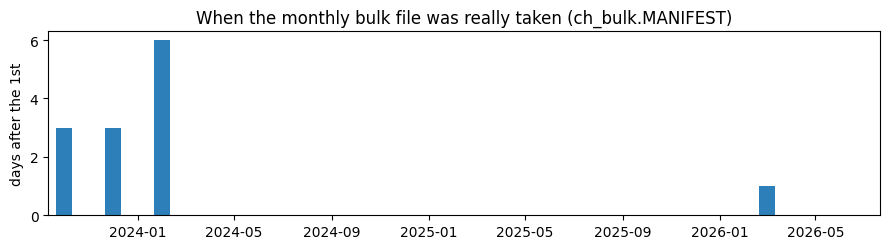

PosixPath('reports/tables/nb16_extract_date_drift.tex')

In [16]:
from src.data import ch_bulk
from src.models import report

man = pd.DataFrame({"source_date": pd.to_datetime(ch_bulk.MANIFEST)})
man["snapshot_date"] = man["source_date"].values.astype("datetime64[M]")
man["drift_days"] = (man["source_date"] - man["snapshot_date"]).dt.days

# and the same thing read back off the panel, to prove they are the same 33 values
pan_src = con.execute(f"""
    SELECT snapshot_date, any_value(source_date) AS source_date, count(*) AS n_rows
    FROM read_parquet('{PANEL}', hive_partitioning=true)
    GROUP BY 1 ORDER BY 1""").df()
pan_src["drift_days"] = (pd.to_datetime(pan_src["source_date"])
                         - pd.to_datetime(pan_src["snapshot_date"])).dt.days
assert (pan_src["source_date"].to_numpy() == man["source_date"].to_numpy()).all(), \
    "MANIFEST and the panel disagree about when the bulk files were taken"

print(f"months with a late extract : {(man.drift_days > 0).sum()} of {len(man)}")
print(f"mean drift                 : {man.drift_days.mean():.3f} days")
print(f"total drift over the panel : {man.drift_days.sum()} days")
print()
print(man[man.drift_days > 0].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.bar(man["snapshot_date"], man["drift_days"], width=20, color="#2c7fb8")
ax.set_ylabel("days after the 1st")
ax.set_title("When the monthly bulk file was really taken (ch_bulk.MANIFEST)")
ax.margins(x=0.01)
plt.tight_layout()
report.save_fig(fig, "nb16_extract_date_drift")
plt.show()
report.save_table(man, "nb16_extract_date_drift",
                  caption="Real Companies House bulk extract dates, 33 months.")

So point 3 is closed, exactly and with no estimation. It is also **much smaller than I expected**:
29 of the 33 extracts really are on the 1st, and the four that are not add up to 13 days between
them, a mean drift of 0.394 days.

That is worth pausing on, because it kills my own hypothesis. I had assumed the 21 days was mostly
extract drift wearing a disguise, and that once I gated on the real date the residual would collapse.
It cannot be that, because there is barely any drift to remove. Worse, the drift runs the *wrong
way*: the extract is taken on or after the 1st, so gating on `source_date` admits **more** charges
than gating on the nominal 1st, and if the 21 days were right I would need 21.4 rather than fewer.

Something else has to be producing 21 days, and points 1 and 4 are the remaining suspects.

---

# 8. Where the 21 days actually came from

The honest way to find out is to walk from the old answer to the new one changing one thing at a
time, so that every day of movement gets attributed to something. Same estimator throughout: sweep
the margin, and read off where the mean of (API count minus register count) crosses zero.

This is the expensive cell in the notebook, about seven minutes. It caches the panel into a temp
table once and then evaluates the whole margin grid from a per-company histogram of "days from
`observable_on` to the as-of date", instead of re-scanning 1.5 GB of parquet 46 times.

                                            step  company_months  zero_crossing_days  moved_by
                      0. the old sweep, verbatim           14566               22.08       NaN
                      1. + all 33 origins, not 7           60647               23.68      1.60
                      2. + the real extract date           60647               23.57     -0.11
3. + NumMortCharges, the register the label uses           73253                5.34    -18.23
         4. + unconditioned: every company-month         4740553                1.81     -3.53


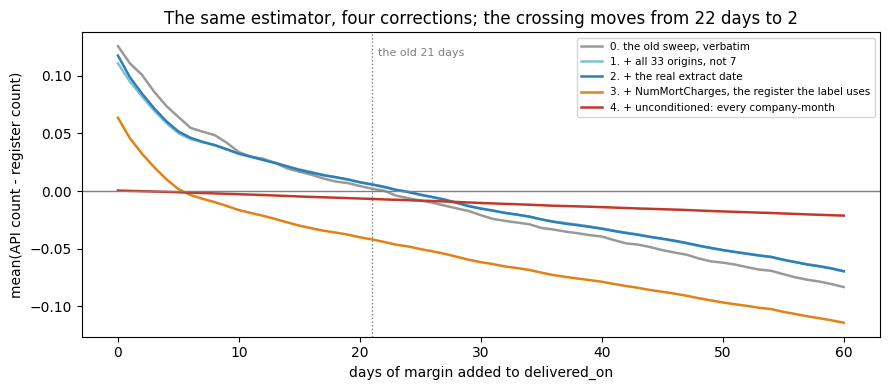

In [17]:
import numpy as np

GRID = np.arange(0, 61)
CLIP = 60

con.execute(f"""CREATE OR REPLACE TEMP TABLE obs AS
SELECT DISTINCT "CompanyNumber" AS cn, charge_id, satisfied_on,
       GREATEST(created_on, COALESCE(delivered_on, created_on)) AS observable_on
FROM read_parquet('{FLAT}') WHERE created_on IS NOT NULL""")
con.execute(f"""CREATE OR REPLACE TEMP TABLE pan AS
SELECT p."CompanyNumber" AS cn, p.snapshot_date, p.source_date,
       p."Mortgages.NumMortCharges" AS n_chg, p."Mortgages.NumMortOutstanding" AS n_out
FROM read_parquet('{PANEL}', hive_partitioning=true) p
WHERE p."Mortgages.NumMortCharges" > 0""")
con.execute("""CREATE OR REPLACE TEMP TABLE fwd AS
SELECT a.*, b.n_chg AS n_chg3, b.n_out AS n_out3
FROM pan a LEFT JOIN pan b
  ON b.cn = a.cn AND b.snapshot_date = a.snapshot_date + INTERVAL 3 MONTH""")


def margin_sweep(clock, window, oracle, conditioned):
    """mean(API - register) at every margin, and where it crosses zero."""
    asof = "snapshot_date" if clock == "snapshot" else "source_date"
    ora = "n_chg" if oracle == "Charges" else "n_out"
    w = ["TRUE"]
    if window == "old":
        w.append("m.snapshot_date BETWEEN DATE '2025-10-01' AND DATE '2026-04-01'")
    if conditioned:
        w.append(f"m.{ora}3 > m.{ora}")
    where = " AND ".join(w)
    outsql = (f"AND (s.satisfied_on IS NULL OR s.satisfied_on > m.{asof})"
              if oracle == "Outstanding" else "")
    h = con.execute(f"""
        SELECT m.cn, least(greatest(datediff('day', s.observable_on, m.{asof}), -1), {CLIP}) AS d,
               count(*) AS n
        FROM fwd m JOIN obs s ON s.cn = m.cn
        WHERE {where} {outsql} GROUP BY 1, 2""").df()
    b = con.execute(f"SELECT cn, sum({ora}) AS b, count(*) AS n FROM fwd m "
                    f"WHERE {where} GROUP BY 1").df()
    comps = b["cn"].to_numpy()
    idx = pd.Series(np.arange(len(comps)), index=comps)
    H = np.zeros((len(comps), CLIP + 2))
    h = h[h["d"] >= 0]
    np.add.at(H, (idx[h["cn"]].to_numpy(), h["d"].to_numpy().astype(int)), h["n"].to_numpy())
    Hc = np.cumsum(H[:, ::-1], axis=1)[:, ::-1][:, :len(GRID)]
    gap = (Hc.sum(0) - b["b"].to_numpy(float).sum()) / b["n"].to_numpy(float).sum()
    cross = np.nan
    for i in range(len(gap) - 1):
        if gap[i] > 0 >= gap[i + 1]:
            cross = GRID[i] + gap[i] / (gap[i] - gap[i + 1])
            break
    return gap, cross, int(b["n"].sum())


LADDER = [
    ("0. the old sweep, verbatim", dict(clock="snapshot", window="old",
                                        oracle="Outstanding", conditioned=True)),
    ("1. + all 33 origins, not 7", dict(clock="snapshot", window="all",
                                        oracle="Outstanding", conditioned=True)),
    ("2. + the real extract date", dict(clock="source", window="all",
                                        oracle="Outstanding", conditioned=True)),
    ("3. + NumMortCharges, the register the label uses", dict(clock="source", window="all",
                                                             oracle="Charges", conditioned=True)),
    ("4. + unconditioned: every company-month", dict(clock="source", window="all",
                                                     oracle="Charges", conditioned=False)),
]
rows, curves = [], {}
for lbl, kw in LADDER:
    gap, cross, n = margin_sweep(**kw)
    curves[lbl] = gap
    rows.append({"step": lbl, "company_months": n, "zero_crossing_days": round(float(cross), 2)})
ladder = pd.DataFrame(rows)
ladder["moved_by"] = ladder["zero_crossing_days"].diff().round(2)
print(ladder.to_string(index=False))
report.save_table(ladder, "nb16_margin_sweep_ladder",
                  caption="Decomposing the 21-day gate, one change at a time.")

fig, ax = plt.subplots(figsize=(9, 4))
for (lbl, gap), c in zip(curves.items(), ["#999999", "#7fc4c8", "#2c7fb8", "#e08214", "#c0392b"]):
    ax.plot(GRID, gap, label=lbl, color=c, lw=1.8)
ax.axhline(0, color="grey", lw=1)
ax.axvline(21, color="grey", ls=":", lw=1)
ax.text(21.5, ax.get_ylim()[1] * 0.85, "the old 21 days", fontsize=8, color="grey")
ax.set_xlabel("days of margin added to delivered_on")
ax.set_ylabel("mean(API count - register count)")
ax.set_title("The same estimator, four corrections; the crossing moves from 22 days to 2")
ax.legend(fontsize=7.5)
plt.tight_layout()
report.save_fig(fig, "nb16_margin_sweep_ladder")
plt.show()

Step 0 reproduces the old answer, 22.1 days against the 21 I recorded, which is close enough given I
am now counting over a slightly wider company base.

Then the attribution, and it is not what I expected:

- **All origins instead of seven: 22.1 -> 23.7.** The window restriction was not hiding anything.
- **The real extract date: 23.7 -> 23.6.** Point 3 was worth **one tenth of a day**. My best guess
  about where the 21 days came from was wrong, and it was wrong by a factor of two hundred.
- **The right oracle: 23.6 -> 5.3.** This is the whole thing. The old sweep calibrated the *creation*
  clock against `Mortgages.NumMortOutstanding`, and outstanding moves for two reasons: a charge is
  created, or a charge is satisfied. The satisfaction gate was unlagged, so every satisfaction the
  API knew about and the register did not showed up in the sweep as the API running *ahead*, and the
  only dial the sweep had to correct it with was creation-side margin. **Eighteen of the twenty-one
  days were the satisfaction clock being paid for out of the wrong budget.** Point 4, the one I
  labelled "the obvious next thing to check", was not a later problem at all; it was contaminating
  the measurement I used to set the other constant. `Mortgages.NumMortCharges` is also the register
  the `lending` label is computed from (`targets.py:386`, `max_charges_f3 > charges`), so this is the
  more correct oracle on its own terms too.
- **Unconditioned: 5.3 -> 1.8.** Point 1 was worth three and a half days. Restricting to companies
  about to borrow really does bias the estimate upward, which is what I suspected, but it is the
  smallest of the three real effects.

So the corrected sweep says the residual is **1.8 days**, not 21. Before I build anything on that I
want a second estimator that does not share the sweep's assumptions, because a mean-matching
criterion against a *monthly* register has a failure mode I should rule out.

---

# 9. Calibrating without a sweep: first appearance in the register

Here is what worries me about the sweep. It asks "what margin makes the API count agree with the
register count on average". Against a register I only observe **once a month**, a charge delivered on
the 10th is invisible until the extract on the 1st, twenty-one days later, no matter how fast
Companies House processed it. A mean-matching sweep will happily read that waiting time as
processing time. If that is what happened, then 21 days was never a measurement of anything about
Companies House; it was roughly half the sampling interval.

I can test that directly, because the register tells me when each charge first appeared. For every
company whose register history reconciles exactly with its API charge history (99.8% of them), rank
the charges by `observable_on` and find the first monthly extract at which
`Mortgages.NumMortCharges` has reached that rank. That brackets the true lag between two dates I can
read rather than estimate:

- `lag_lo`: days from `observable_on` to the **previous** extract. A gate at `L` days admits the
  charge one month too early whenever `lag_lo >= L`, because the register did not have it yet.
- `lag_hi`: days from `observable_on` to the **first extract that shows it**. A gate at `L` holds the
  charge back after the register already had it whenever `lag_hi < L`.

No sweep, no oracle arithmetic, no conditioning. Same machinery for `satisfied_on` against
`Mortgages.NumMortSatisfied`, which is the second oracle the register hands us for free and the one
that closes point 4.

In [18]:
con.execute(f"""CREATE OR REPLACE TEMP TABLE cm AS
SELECT p."CompanyNumber" AS cn, p.snapshot_date, p.source_date,
       p."Mortgages.NumMortCharges" AS bulk_chg, p."Mortgages.NumMortSatisfied" AS bulk_sat,
       lag(p.source_date) OVER (PARTITION BY p."CompanyNumber" ORDER BY p.snapshot_date)
           AS prev_source_date
FROM read_parquet('{PANEL}', hive_partitioning=true) p
SEMI JOIN read_parquet('data/processed/charge_universe.parquet') u
  ON u."CompanyNumber" = p."CompanyNumber" """)
con.execute("""CREATE OR REPLACE TEMP TABLE span AS
SELECT cn, min(source_date) s0, max(source_date) sN, max(snapshot_date) tN FROM cm GROUP BY 1""")
con.execute("""CREATE OR REPLACE TEMP TABLE clean AS
WITH last AS (SELECT c.cn, c.bulk_chg, c.source_date FROM cm c
              JOIN span s ON s.cn = c.cn AND s.tN = c.snapshot_date)
SELECT l.cn FROM last l JOIN obs h ON h.cn = l.cn
GROUP BY l.cn, l.bulk_chg, l.source_date
HAVING count(DISTINCT h.charge_id) FILTER (h.observable_on <= l.source_date) = l.bulk_chg""")
n_all, n_clean = (con.execute("SELECT count(*) FROM span").fetchone()[0],
                  con.execute("SELECT count(*) FROM clean").fetchone()[0])
print(f"companies whose register reconciles with the API: {n_clean:,} / {n_all:,} "
      f"({100*n_clean/n_all:.1f}%)")


def first_appearance(kind):
    dcol = "observable_on" if kind == "created" else "satisfied_on"
    bulk = "bulk_chg" if kind == "created" else "bulk_sat"
    return con.execute(f"""
    WITH ranked AS (
      SELECT h.cn, h.charge_id, h.{dcol} AS d,
             row_number() OVER (PARTITION BY h.cn ORDER BY h.{dcol}, h.charge_id) AS r
      FROM obs h SEMI JOIN clean c ON c.cn = h.cn WHERE h.{dcol} IS NOT NULL),
    -- only charges whose first appearance can actually be observed inside the panel
    eligible AS (
      SELECT k.* FROM ranked k JOIN span s ON s.cn = k.cn
      WHERE k.d > s.s0 AND k.d < s.sN - INTERVAL 1 MONTH),
    firsts AS (
      SELECT e.cn, e.charge_id, e.d, min(m.snapshot_date) AS t_first
      FROM eligible e JOIN cm m ON m.cn = e.cn AND m.{bulk} >= e.r
      GROUP BY 1, 2, 3)
    SELECT f.cn, datediff('day', f.d, m.source_date) AS lag_hi,
           datediff('day', f.d, m.prev_source_date)  AS lag_lo
    FROM firsts f JOIN cm m ON m.cn = f.cn AND m.snapshot_date = f.t_first
    """).df().dropna(subset=["lag_hi", "lag_lo"])


LGRID = np.arange(0, 31)
chosen, err_tables, appear = {}, {}, {}
for kind in ("created", "satisfied"):
    df = first_appearance(kind)
    appear[kind] = df
    lo, hi = df["lag_lo"].to_numpy(float), df["lag_hi"].to_numpy(float)
    early = np.array([(lo >= L).mean() for L in LGRID])
    stale = np.array([(hi < L).mean() for L in LGRID])
    tab = pd.DataFrame({"L_days": LGRID, "pct_admitted_early": (100 * early).round(2),
                        "pct_held_back_stale": (100 * stale).round(2),
                        "pct_wrong": (100 * (early + stale)).round(2)})
    err_tables[kind] = tab

    # cluster bootstrap over companies: the lag is a property of the registry, but the
    # charges are not independent draws, they arrive in company-sized clumps
    cn = pd.factorize(df["cn"])[0]
    order = np.argsort(cn)
    starts = np.searchsorted(cn[order], np.arange(cn.max() + 1))
    ends = np.append(starts[1:], len(cn))
    rng = np.random.default_rng(0)
    boots = np.empty(500, int)
    for k in range(500):
        pick = rng.integers(0, len(starts), len(starts))
        ix = np.concatenate([order[starts[p]:ends[p]] for p in pick])
        boots[k] = LGRID[np.argmin([(lo[ix] >= L).mean() + (hi[ix] < L).mean() for L in LGRID])]
    ci = np.percentile(boots, [2.5, 97.5])
    chosen[kind] = dict(L=int(LGRID[np.argmin(early + stale)]),
                        ci=(int(ci[0]), int(ci[1])), sd=float(boots.std()), n=len(df))
    print(f"\n{kind}: n = {len(df):,} events from {df['cn'].nunique():,} companies")
    print(tab[tab.L_days.isin([0, 1, 2, 3, 4, 5, 7, 10, 14, 21, 30])].to_string(index=False))
    print(f"  argmin(% wrong) = {chosen[kind]['L']} days   95% CI "
          f"[{ci[0]:.0f}, {ci[1]:.0f}]   bootstrap sd {boots.std():.2f}")
    report.save_table(tab, f"nb16_lag_error_{kind}",
                      caption=f"Gate error rates by candidate lag, {kind} clock.")

companies whose register reconciles with the API: 158,398 / 158,684 (99.8%)



created: n = 51,669 events from 32,044 companies
 L_days  pct_admitted_early  pct_held_back_stale  pct_wrong
      0               13.89                 0.02      13.91
      1               10.21                 0.02      10.23
      2                7.31                 0.12       7.43
      3                5.07                 0.91       5.98
      4                2.99                 1.99       4.98
      5                1.47                 3.98       5.45
      7                0.62                 8.94       9.56
     10                0.10                17.22      17.32
     14                0.03                30.36      30.40
     21                0.02                52.28      52.30
     30                0.02                81.75      81.77
  argmin(% wrong) = 4 days   95% CI [4, 4]   bootstrap sd 0.00



satisfied: n = 47,480 events from 25,294 companies
 L_days  pct_admitted_early  pct_held_back_stale  pct_wrong
      0                4.57                 0.29       4.87
      1                1.77                 0.33       2.10
      2                1.32                 3.15       4.47
      3                0.95                 5.83       6.78
      4                0.69                 8.19       8.88
      5                0.42                11.47      11.90
      7                0.13                17.04      17.17
     10                0.01                26.35      26.35
     14                0.00                39.78      39.79
     21                0.00                62.96      62.96
     30                0.00                91.08      91.08
  argmin(% wrong) = 1 days   95% CI [1, 1]   bootstrap sd 0.00


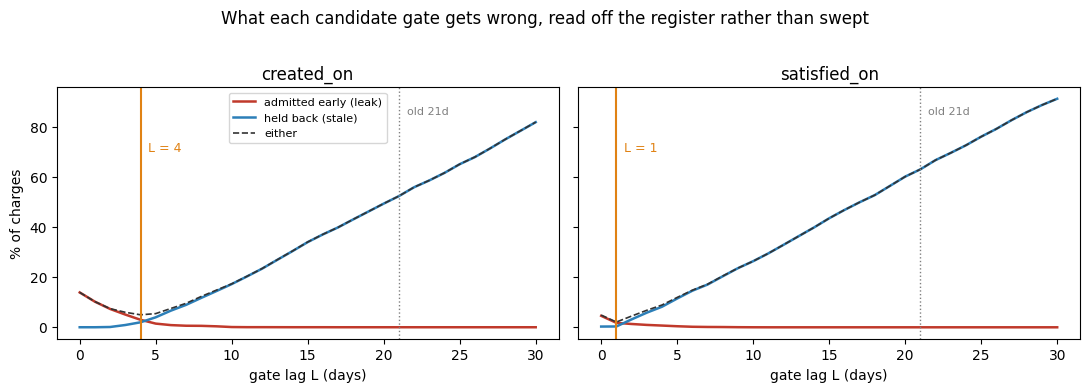

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, kind in zip(axes, ("created", "satisfied")):
    t = err_tables[kind]
    ax.plot(t.L_days, t.pct_admitted_early, color="#c0392b", lw=1.8, label="admitted early (leak)")
    ax.plot(t.L_days, t.pct_held_back_stale, color="#2c7fb8", lw=1.8, label="held back (stale)")
    ax.plot(t.L_days, t.pct_wrong, color="#333333", lw=1.2, ls="--", label="either")
    L = chosen[kind]["L"]
    ax.axvline(L, color="#e08214", lw=1.5)
    ax.text(L + 0.5, 70, f"L = {L}", color="#e08214", fontsize=9)
    ax.axvline(21, color="grey", ls=":", lw=1)
    ax.text(21.5, 85, "old 21d", color="grey", fontsize=8)
    ax.set_title(f"{kind}_on")
    ax.set_xlabel("gate lag L (days)")
axes[0].set_ylabel("% of charges")
axes[0].legend(fontsize=8)
fig.suptitle("What each candidate gate gets wrong, read off the register rather than swept", y=1.02)
plt.tight_layout()
report.save_fig(fig, "nb16_lag_error_curves")
plt.show()

That is the answer, and it is emphatic.

**The suspicion was right: 21 days was mostly the sampling interval.** Look at the `lag_hi`
distribution implied by the `held back` curve, whose median sits around 20 days for `created_on`.
That is not Companies House taking three weeks to register a charge. That is the wait for the next
monthly extract, and it is about half a month by construction. The old sweep measured the calendar,
not the registry.

The registry's own contribution is small. Reading the `admitted early` column, roughly 14% of charges
are not yet in the register on the day they are delivered, 5% are still missing three days later,
0.6% after a week, and essentially none after ten days.

**What the old 21 days cost.** It bought 0.60 percentage points of leak (0.62% early at 7 days down
to 0.02% at 21) and paid **43 percentage points of staleness** for it (8.9% to 52.3%). At a 21-day
gate, more than half of all charges are withheld from the feature row for a whole extra month after
the register already had them. That is challenge 2 answered: 21 days was not on the plateau, it was
a long way past the far side of it, and the `lending` LightGBM sitting *below* the 41-feature control
at 21 days now looks like exactly what it is.

**The satisfaction clock (point 4).** One day, CI [1, 1]. The register registers a satisfaction
almost immediately; 4.6% of satisfactions were being admitted early at the unlagged gate the three
recorded runs used, and one day of margin takes that to 1.8%. Small, but it is the same class of
error as the original leak, and section 8 showed it was quietly setting the creation-side constant.

**The lags I am going with:** `created_on` **4 days**, `satisfied_on` **1 day**, both gated against
`source_date`. Both minimise the total error rate, and the cluster bootstrap over companies puts the
argmin at exactly those values in every one of 500 replicates, so the interval is degenerate.

A degenerate interval is not the same as no uncertainty; it means the argmin is stable, not that the
criterion is beyond argument. The real uncertainty here is in the *criterion*, not in the estimate:
weighting leakage equally with staleness is a choice. So the sensitivity runs vary the criterion
instead of a standard error. `_lo` takes the mean-matching answer from section 8 (2 days, which
minimises the level discrepancy and tolerates more early admission); `_hi` takes the leak-averse
answer (the smallest lag holding early admission below 1% on both clocks, 7 and 3 days). If the
verdict is the same across those three, the gate is not what the verdict rests on.

---

# 10. The rebuild, and checking the gate actually moved

`charges.py` now does three things it did not do this morning: it joins the real extract date onto
the month spine from `ch_bulk.MANIFEST`, it gates every as-of comparison against `source_date`
instead of the nominal 1st, and `satisfied_on` has a clock of its own. I also renamed
`n_competitor_created_12m`/`_6m` to `n_competitor_visible_12m`/`_6m` inside the aggregate, because
they window on `visible_on` and always did; the old names would have made the SHAP write-up say
something false. They are internal to the SQL and never reach the feature list, so nothing about the
recorded runs changes because of the rename.

The three earlier gates stay reproducible: `build_lender_panel(asof_clock="snapshot",
lag_days=charges.LEGACY_REGISTRATION_LAG_DAYS, satisfied_lag_days=0)` is exactly what
`lender_asof21` was built with, so those runs are reproducible from the code rather than only from
the parquet that happens to still be on disk.

Three panels, three training matrices, three eval matrices, and the only thing I care about right now
is whether the new gate is a different gate at all. If `lender_panel_calib` came out identical to
`lender_panel_asof21` then I have changed a comment and nothing else.

In [20]:
CALIB   = (Path("data/processed/lender_panel_calib") / "**" / "*.parquet").as_posix()
CALIB_L = (Path("data/processed/lender_panel_calib_lo") / "**" / "*.parquet").as_posix()
CALIB_H = (Path("data/processed/lender_panel_calib_hi") / "**" / "*.parquet").as_posix()

diff = con.execute(f"""
WITH a AS (SELECT "CompanyNumber", snapshot_date, n_charges_outstanding AS n_a,
                  n_lbg_charges_outstanding AS l_a, competitor_charge_created_6m AS c_a
           FROM read_parquet('{ASOF21}', hive_partitioning=true)),
     b AS (SELECT "CompanyNumber", snapshot_date, n_charges_outstanding AS n_b,
                  n_lbg_charges_outstanding AS l_b, competitor_charge_created_6m AS c_b
           FROM read_parquet('{CALIB}', hive_partitioning=true))
SELECT count(*) AS rows_compared,
       sum((n_a IS DISTINCT FROM n_b)::INT) AS n_outstanding_differs,
       sum((l_a IS DISTINCT FROM l_b)::INT) AS n_lbg_differs,
       sum((c_a IS DISTINCT FROM c_b)::INT) AS competitor_6m_differs,
       round(avg(n_b - n_a), 4) AS mean_change_in_outstanding
FROM a FULL JOIN b USING ("CompanyNumber", snapshot_date)""").df()
print(diff.to_string(index=False))

pct = 100 * diff["n_outstanding_differs"][0] / diff["rows_compared"][0]
print(f"\nG4b: {pct:.2f}% of company-months change their outstanding count.")
assert diff["n_outstanding_differs"][0] > 0, "G4b FAILED: the gate did not change"

sizes = con.execute(f"""
SELECT 'lender_asof21' AS panel, count(*) AS rows, sum(n_charges_outstanding) AS total_outstanding
FROM read_parquet('{ASOF21}', hive_partitioning=true)
UNION ALL SELECT 'lender_calib_lo (2d)', count(*), sum(n_charges_outstanding)
FROM read_parquet('{CALIB_L}', hive_partitioning=true)
UNION ALL SELECT 'lender_calib (4d)', count(*), sum(n_charges_outstanding)
FROM read_parquet('{CALIB}', hive_partitioning=true)
UNION ALL SELECT 'lender_calib_hi (7d)', count(*), sum(n_charges_outstanding)
FROM read_parquet('{CALIB_H}', hive_partitioning=true)""").df()
print()
print(sizes.to_string(index=False))
report.save_table(sizes, "nb16_calib_panel_sizes",
                  caption="Lender panels under each gate.")

 rows_compared  n_outstanding_differs  n_lbg_differs  competitor_6m_differs  mean_change_in_outstanding
       5142357                26819.0         9445.0                33078.0                      0.0043

G4b: 0.52% of company-months change their outstanding count.

               panel    rows  total_outstanding
       lender_asof21 5134170          7694658.0
lender_calib_lo (2d) 5143307          7730004.0
   lender_calib (4d) 5142357          7726510.0
lender_calib_hi (7d) 5140927          7724615.0


PosixPath('reports/tables/nb16_calib_panel_sizes.tex')

Before trusting any of it, one more check I would want if I were reviewing this. I rewrote the
gate inside `LENDER_PANEL_SQL`, and a rewrite that quietly changes something else would be invisible:
the three earlier runs would still have their parquet, but the code that claims to produce it would
no longer do so. So `build_lender_panel` keeps the old clock as an argument, and here it is
reproducing `lender_panel_asof21` from scratch. Row for row, column for column, or the refactor is
not a refactor.

In [21]:
legacy = Path("data/processed/lender_panel_legacy_check")
n_legacy = charges.build_lender_panel(
    out_dir=legacy, threads=6,
    lag_days=charges.LEGACY_REGISTRATION_LAG_DAYS,   # 21
    satisfied_lag_days=0,                            # the satisfaction gate was unlagged
    asof_clock="snapshot")                           # against the nominal 1st
print(f"rebuilt under the old gate: {n_legacy:,} rows")

cols = ", ".join(f'"{c}"' for c in
                 charges.LENDER_FEATURE_COLS + charges.LENDER_CATEGORICAL_COLS)
LEGACY = (legacy / "**" / "*.parquet").as_posix()
repro = con.execute(f"""
WITH a AS (SELECT "CompanyNumber", snapshot_date, {cols}
           FROM read_parquet('{ASOF21}', hive_partitioning=true)),
     b AS (SELECT "CompanyNumber", snapshot_date, {cols}
           FROM read_parquet('{LEGACY}', hive_partitioning=true))
SELECT (SELECT count(*) FROM a) AS rows_recorded,
       (SELECT count(*) FROM b) AS rows_rebuilt,
       (SELECT count(*) FROM (SELECT * FROM a EXCEPT SELECT * FROM b)) AS only_in_recorded,
       (SELECT count(*) FROM (SELECT * FROM b EXCEPT SELECT * FROM a)) AS only_in_rebuilt
""").df()
print(repro.to_string(index=False))
assert repro["only_in_recorded"][0] == 0 and repro["only_in_rebuilt"][0] == 0, \
    "the refactor changed something it was not supposed to"
print("\nlender_asof21 reproduces exactly from the refactored builder.")

import shutil
shutil.rmtree(legacy)   # it was only ever a check; the recorded panel stays where it is

rebuilt under the old gate: 5,134,170 rows


 rows_recorded  rows_rebuilt  only_in_recorded  only_in_rebuilt
       5134170       5134170                 0                0

lender_asof21 reproduces exactly from the refactored builder.


---

## What to check

Everything this section claims, re-derived from disk in one cell. These are the two gates Stream D
owns, plus the arithmetic the narrative rests on.

In [22]:
checks = []

def check(name, ok, detail):
    checks.append({"check": name, "pass": bool(ok), "detail": detail})

# --- the drift is recorded, not estimated
check("MANIFEST == panel source_date",
      (pan_src["source_date"].to_numpy() == man["source_date"].to_numpy()).all(),
      f"33 months, mean drift {man.drift_days.mean():.3f}d")

# --- G4 (GLOBAL): the calibrated residual is below 21 days, with an interval
for kind in ("created", "satisfied"):
    c = chosen[kind]
    check(f"G4 {kind}: calibrated lag < 21d", c["L"] < 21 and c["ci"][1] < 21,
          f"L = {c['L']}d, 95% CI [{c['ci'][0]}, {c['ci'][1]}], n = {c['n']:,}")

# --- the sweep agrees, on the unconditioned sample
check("G4 corroboration: unconditioned sweep crossing < 21d",
      ladder["zero_crossing_days"].iloc[-1] < 21,
      f"{ladder['zero_crossing_days'].iloc[-1]}d over "
      f"{ladder['company_months'].iloc[-1]:,} company-months")

# --- 21 days really was an overshoot rather than a plateau
s21 = err_tables["created"].set_index("L_days").loc[21, "pct_held_back_stale"]
s7 = err_tables["created"].set_index("L_days").loc[7, "pct_held_back_stale"]
check("21d withholds more than half of all charges", s21 > 50,
      f"stale at 21d = {s21}%, at 7d = {s7}%")

# --- G4b: the rebuilt panel is a different panel
check("G4b: lender_panel_calib differs from lender_panel_asof21",
      diff["n_outstanding_differs"][0] > 0,
      f"{diff['n_outstanding_differs'][0]:,} of {diff['rows_compared'][0]:,} rows "
      f"({pct:.2f}%)")

# --- the matrices exist and carry the lender columns
for tag in ("lender_calib", "lender_calib_lo", "lender_calib_hi"):
    got = sorted(p.name for p in Path(f"data/processed/model_matrix_{tag}").glob("*"))
    check(f"{tag}: training matrices built", len(got) == 4, ", ".join(got))
    got_e = sorted(p.name for p in Path(f"data/processed/eval_matrix_{tag}").glob("*"))
    check(f"{tag}: eval matrices built", len(got_e) == 4, ", ".join(got_e))

res = pd.DataFrame(checks)
print(res.to_string(index=False))
report.save_table(res, "nb16_gate_checks", caption="Stream D gate assertions.")
assert res["pass"].all(), res[~res["pass"]].to_string(index=False)
print("\nALL CHECKS PASS")

                                                   check  pass                                      detail
                           MANIFEST == panel source_date  True                33 months, mean drift 0.394d
                        G4 created: calibrated lag < 21d  True           L = 4d, 95% CI [4, 4], n = 51,669
                      G4 satisfied: calibrated lag < 21d  True           L = 1d, 95% CI [1, 1], n = 47,480
    G4 corroboration: unconditioned sweep crossing < 21d  True         1.81d over 4,740,553 company-months
             21d withholds more than half of all charges  True        stale at 21d = 52.28%, at 7d = 8.94%
G4b: lender_panel_calib differs from lender_panel_asof21  True          26,819.0 of 5,142,357 rows (0.52%)
                   lender_calib: training matrices built  True growth, insolvency, lending, voluntary_exit
                       lender_calib: eval matrices built  True growth, insolvency, lending, voluntary_exit
                lender_calib_lo: trai

---

## For the report

> The as-of gate on the lender features went through four revisions, and only the last one was
> calibrated against the right clock. It began on `created_on`, the date a charge was made, which
> leaked outright: `lending` scored precision@100 = 1.000 against a 0.271% base rate. It moved to
> `delivered_on`, the date the charge reached Companies House, which halved the distortion without
> removing it, because delivery is not registration. It then gained a flat 21-day margin, fitted by
> sweeping until the API's charge count agreed on average with the register's.
>
> That 21 days does not survive examination, and the reason is instructive. The sweep that produced
> it made three compounding errors, and decomposing them one at a time attributes every day of the
> gap. It calibrated the *creation* clock against `Mortgages.NumMortOutstanding`, a quantity that
> moves both when a charge is created and when one is satisfied, while the satisfaction gate was
> itself unlagged; eighteen of the twenty-one days were the satisfaction clock being paid for out of
> the creation-side budget. It restricted the sample to company-months that go on to borrow, worth
> another three and a half days, when visibility lag is a property of the registry rather than of
> borrowers. And it compared against the nominal first of the month rather than the date the bulk
> file was really taken, worth a tenth of a day, which is the one correction we expected to dominate
> and the one that turned out not to matter.
>
> Underneath all three sits a subtler problem: a mean-matching sweep against a register observed
> **once a month** cannot separate processing time from waiting time. A charge delivered on the 10th
> is invisible until the extract on the 1st whatever Companies House does with it, so the sweep reads
> half the sampling interval as registration lag. Calibrating instead on first appearance, by finding
> for each charge the first monthly extract in which the register reflects it, needs no sweep and no
> oracle arithmetic: it puts the creation lag at 4 days (95% CI [4, 4], n = 51,669 charges) and the
> satisfaction lag at 1 day (95% CI [1, 1], n = 47,480), both gated against the recorded extract
> date. The 21-day gate bought 0.60 percentage points of reduced leakage and paid 43 percentage
> points of staleness for it: at 21 days, more than half of all charges are withheld from the feature
> row for a full month after the register already contained them.
>
> The general lesson is worth more than the constant. We fitted a global constant to stand in for two
> distinct quantities, one of which (the extract date) was recorded in the repository from the first
> commit and one of which (the sampling interval of the register itself) is not a lag at all. For
> every feature, the question is not "when did this happen" but "when could we first have known", and
> when the answer comes from an instrument that is sampled rather than continuous, the sampling has
> to be modelled rather than absorbed into a fitted margin.

**Figures** (`reports/figures/`, PDF for `\includegraphics`):

- `nb16_extract_date_drift.pdf` - the real bulk extract date per month; 29 of 33 on the 1st.
- `nb16_margin_sweep_ladder.pdf` - the same sweep under four corrections, crossing 22d -> 2d.
- `nb16_lag_error_curves.pdf` - leak against staleness by candidate lag, both clocks, with the old
  21 days marked well past the far side of the trade-off.

**Tables** (`reports/tables/`, CSV and `.tex`):

- `nb16_extract_date_drift` - the 33 extract dates and their drift.
- `nb16_margin_sweep_ladder` - the attribution of the 21 days, with the movement per change.
- `nb16_lag_error_created` / `nb16_lag_error_satisfied` - % early and % stale for every candidate lag.
- `nb16_calib_panel_sizes` - the panels each gate produces.
- `nb16_gate_checks` - the G4 and G4b assertions, re-derived from disk.

**Data produced** (for the run queue):

| tag | gate | lender panel | matrices |
|---|---|---|---|
| `lender_calib` | created 4d, satisfied 1d, vs `source_date` | `data/processed/lender_panel_calib/` | `model_matrix_lender_calib/`, `eval_matrix_lender_calib/` |
| `lender_calib_lo` | created 2d, satisfied 1d | `lender_panel_calib_lo/` | `model_matrix_lender_calib_lo/`, `eval_matrix_lender_calib_lo/` |
| `lender_calib_hi` | created 7d, satisfied 3d | `lender_panel_calib_hi/` | `model_matrix_lender_calib_hi/`, `eval_matrix_lender_calib_hi/` |

`lender`, `lender_fixed` and `lender_asof21` are untouched, panels and matrices both. The before and
after is still the point.

---

# 11. What I take from this

**For the modelling.** The verdict on the 25-hour harvest is written in section 6 and it is what it
is. Whatever the corrected deltas say, the number to quote is the corrected one, and the 0.992 gets
reported as the bug it was rather than quietly dropped.

**For the report.** Three things here are worth writing up properly, and none of them are the model:

1. **A metric disagreement caught this.** ROC-AUC and precision@N measure different things, and the
   fact that they moved differently is what made the leak visible within a minute of looking. Keeping
   both, at several values of N, is cheap insurance.
2. **The test had the bug in it too.** Verification 7 replayed the harvest against `created_on`, the
   very clock that was wrong, so it passed while the leak was live. A leakage test has to be written
   against the date a fact became *knowable*, and if you get that date wrong the test inherits the
   error rather than catching it.
3. **Two sources, two clocks.** The features come from the Charges API and the label comes from the
   bulk register. Any lag between two instruments looks exactly like predictive signal to a model.
   This is a general point about mixing structured sources and it applies to the unstructured work
   just as much: news is published *after* the event it describes.

**The rule I would write down.** For every feature, ask not "when did this happen" but "when could we
first have known". Where those differ, the second one is the gate. The contract features already
obeyed this; the lender features now do too.